In [7]:
import numpy as np

rng = np.random.default_rng(seed= 42)
m = 200
X = 2 * rng.random((m, 1))
y = 4 + 3 * X + rng.standard_normal((m, 1))

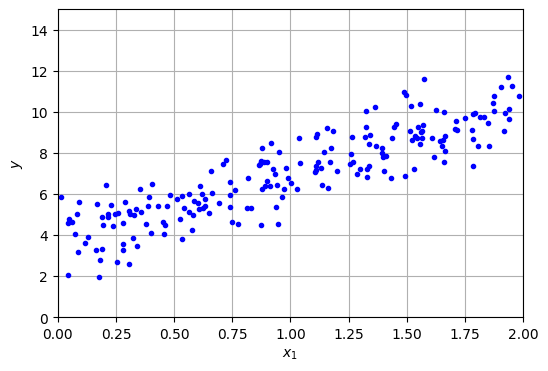

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$")
plt.axis([0,2,0,15])
plt.grid()
plt.show()

In [17]:
from sklearn.preprocessing import add_dummy_feature

Xb = add_dummy_feature(X)
theta_hat = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ y

In [18]:
X_new = np.array([[0], [2]])
X_newb = add_dummy_feature(X_new)
y_predict = X_newb @ theta_hat
y_predict

array([[ 3.69084138],
       [10.35005055]])

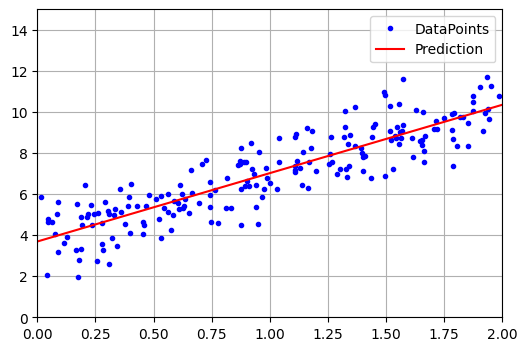

In [20]:
plt.figure(figsize=(6,4))
plt.plot(X, y, "b.", label = "DataPoints")
plt.plot(X_new, y_predict, "r-", label = "Prediction")
plt.grid()
plt.legend()
plt.axis([0,2,0,15])
plt.show()


In [21]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.predict(X_new)

array([[ 3.69084138],
       [10.35005055]])

In [22]:
lin_reg.intercept_, lin_reg.coef_

(array([3.69084138]), array([[3.32960458]]))

In [24]:
np.linalg.pinv(Xb) @ y

array([[3.69084138],
       [3.32960458]])

In [26]:
eta = 0.1
n_epochs = 1000
m = len(Xb)
rng = np.random.default_rng(seed=42)
theta = rng.random((2,1))
for i in range(n_epochs):
    gradient = (2/m) * Xb.T @ (Xb@theta - y)
    theta = theta - eta * gradient

In [27]:
theta

array([[3.69084138],
       [3.32960458]])

(np.float64(0.0), np.float64(160.0), np.float64(0.0), np.float64(2.5))

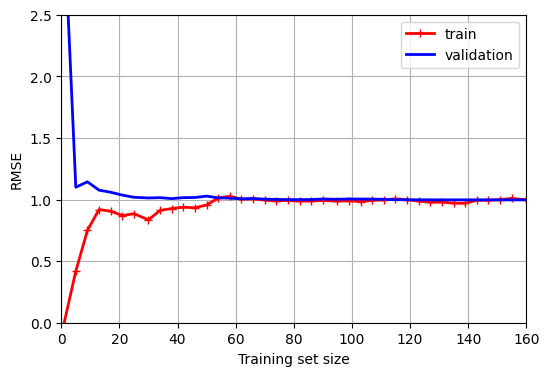

In [31]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(LinearRegression(), X, y, train_sizes= np.linspace(0.01, 1, 40), cv = 5, scoring = "neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis = 1)
valid_errors = -valid_scores.mean(axis = 1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes,train_errors,  "r-+", linewidth = 2, label = "train")
plt.plot(train_sizes, valid_errors, "b-", linewidth = 2, label = "validation")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 160, 0, 2.5])

In [1]:
rng = np.random.default_rng(seed = 42)
m = 200
X = 6 * rng.random((m,1)) - 3
y = 0.5*X**2 + X + 2 + rng.standard_normal((m,1))


NameError: name 'np' is not defined